       Cement  Blast Furnace Slag     Fly Ash       Water  Superplasticizer  \
0  249.816048           55.539879   52.341137  207.451389         17.159876   
1  480.285723          162.570284   49.395760  223.568582         24.162970   
2  392.797577          261.883751  181.250916  152.560827         22.804828   
3  339.463394          219.667466   49.909240  201.233633          4.616997   
4  162.407456          241.968344   54.389945  194.326978          4.477484   

   Coarse Aggregate  Fine Aggregate  Age  Concrete Compressive Strength  
0        957.454208      859.302782  219                      21.810978  
1        989.374264      668.954545   57                      36.547119  
2       1141.818957      948.957825  283                      51.371226  
3        936.001754      845.246496  113                      32.579131  
4       1147.859874      662.881553  133                      10.000998  
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data col

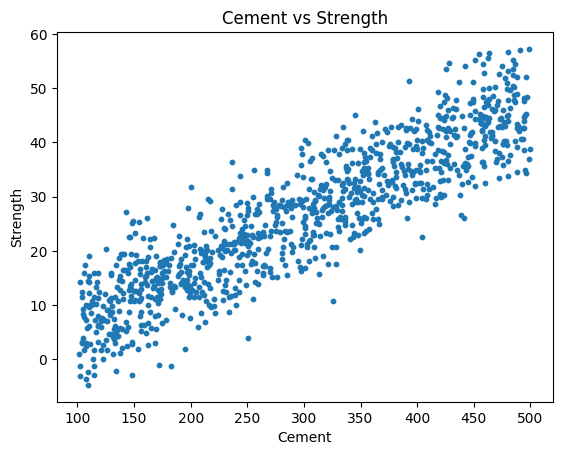

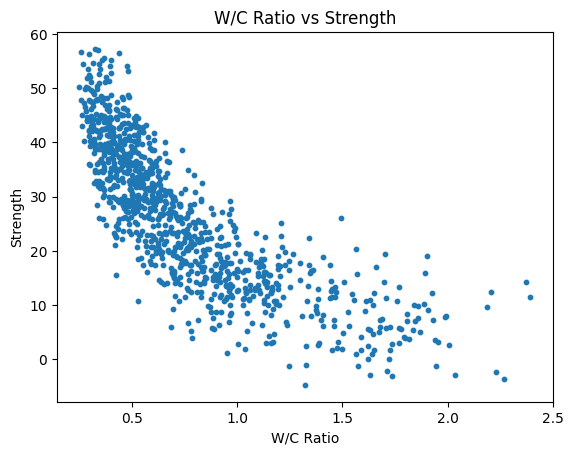

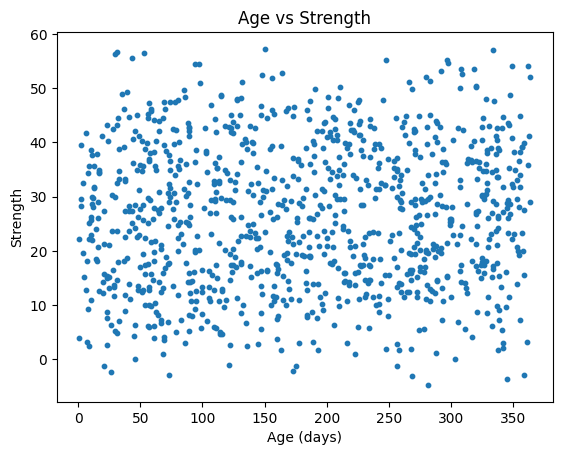


Low: 466
Medium: 504
High: 30


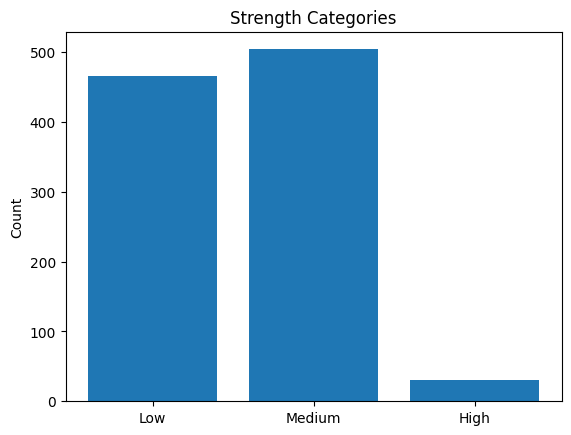


Max strength row:
 Cement                            498.654735
Blast Furnace Slag                214.845202
Fly Ash                            58.923879
Water                             162.413009
Superplasticizer                    7.405711
Coarse Aggregate                 1076.657361
Fine Aggregate                    970.477195
Age                               150.000000
Concrete Compressive Strength      57.256057
Name: 532, dtype: float64

Min strength row:
 Cement                           109.308774
Blast Furnace Slag               154.445206
Fly Ash                          157.797032
Water                            144.403913
Superplasticizer                  25.174398
Coarse Aggregate                 936.827774
Fine Aggregate                   931.044105
Age                              282.000000
Concrete Compressive Strength     -4.730797
Name: 377, dtype: float64

Weakest 5 mixes:
          Cement  Blast Furnace Slag     Fly Ash       Water  Superplasticizer  \
377  10

In [1]:
import pandas as pd          # นำเข้า pandas สำหรับจัดการข้อมูลแบบตาราง
import numpy as np           # นำเข้า numpy สำหรับคำนวณตัวเลข
import matplotlib.pyplot as plt   # ใช้สำหรับวาดกราฟ

# ------------------ 1. LOAD & CLEAN ------------------
df = pd.read_csv("concrete.csv")   # โหลดไฟล์ concrete.csv เป็น DataFrame
df = df.dropna()                   # ลบทุกแถวที่มีค่าว่าง (NA)

print(df.head())                   # แสดง 5 แถวแรกของข้อมูล
print(df.info())                   # แสดงข้อมูลสรุป เช่น dtypes, จำนวนแถว

# numpy arrays
arr = df.to_numpy()                # แปลง DataFrame เป็น numpy array

# ------------------ 2. DESCRIPTIVE STATISTICS ------------------
for col in df.columns:             # วนลูปทุกคอลัมน์ใน DataFrame
    data = df[col].to_numpy()      # ดึงค่าของคอลัมน์นั้นมาเป็น array

    print(f"\n---- {col} ----")     # แสดงชื่อคอลัมน์
    print("Mean:", np.mean(data))  # ค่าเฉลี่ย
    print("Median:", np.median(data))  # ค่ากลาง
    print("Std:", np.std(data))        # ส่วนเบี่ยงเบนมาตรฐาน
    print("Min:", np.min(data), "Max:", np.max(data))  # ค่าต่ำสุดและสูงสุด
    print("P10 P50 P90:", np.percentile(data, [10,50,90]))  # percentile 10, 50, 90

# ------------------ 3. W/C RATIO ------------------
water = df["Water"].to_numpy()     # ดึงข้อมูลปริมาณน้ำเป็น array
cement = df["Cement"].to_numpy()   # ดึงข้อมูลปริมาณซีเมนต์เป็น array

w_c = water / cement               # คำนวณค่า Water/Cement ratio
print("\nW/C ratio stats:", np.mean(w_c), np.min(w_c), np.max(w_c))  # ค่าเฉลี่ย/ต่ำสุด/สูงสุด

print("w/c < 0.4:", np.sum(w_c < 0.4))                       # นับจำนวนสูตรที่ w/c < 0.4
print("0.4–0.6:", np.sum((w_c >= 0.4) & (w_c <= 0.6)))       # นับจำนวนสูตรที่อยู่ระหว่าง 0.4–0.6
print("w/c > 0.6:", np.sum(w_c > 0.6))                        # นับจำนวนสูตรที่ w/c > 0.6

# ------------------ 4. PLOTS ------------------
plt.scatter(df["Cement"], df["Concrete Compressive Strength"], s=10)   # กราฟปริมาณซีเมนต์ vs กำลังอัด
plt.title("Cement vs Strength")                                        # ชื่อกราฟ
plt.xlabel("Cement")                                                   # ป้ายแกน X
plt.ylabel("Strength")                                                 # ป้ายแกน Y
plt.show()                                                             # แสดงกราฟ

plt.scatter(w_c, df["Concrete Compressive Strength"], s=10)            # กราฟ W/C ratio vs strength
plt.title("W/C Ratio vs Strength")
plt.xlabel("W/C Ratio")
plt.ylabel("Strength")
plt.show()

plt.scatter(df["Age"], df["Concrete Compressive Strength"], s=10)      # กราฟ อายุคอนกรีต vs strength
plt.title("Age vs Strength")
plt.xlabel("Age (days)")
plt.ylabel("Strength")
plt.show()

# ------------------ 5. STRENGTH CATEGORIES ------------------
strength = df["Concrete Compressive Strength"].to_numpy()              # ดึงค่ากำลังอัดเป็น array

low = np.sum(strength < 25)                                            # นับกลุ่ม < 25 MPa
mid = np.sum((strength >= 25) & (strength <= 50))                      # นับกลุ่ม 25–50 MPa
high = np.sum(strength > 50)                                           # นับกลุ่ม > 50 MPa

print("\nLow:", low)                                                   # แสดงจำนวนกลุ่ม Low
print("Medium:", mid)                                                  # แสดงจำนวนกลุ่ม Medium
print("High:", high)                                                   # แสดงจำนวนกลุ่ม High

plt.bar(["Low", "Medium", "High"], [low, mid, high])                   # วาด bar chart ของแต่ละกลุ่ม
plt.title("Strength Categories")
plt.ylabel("Count")
plt.show()

# ------------------ 6. EXTREME CASES ------------------
imax = np.argmax(strength)                                             # หา index ของกำลังอัดที่สูงที่สุด
imin = np.argmin(strength)                                             # หา index ของกำลังอัดต่ำที่สุด

print("\nMax strength row:\n", df.iloc[imax])                          # แสดงข้อมูลแถวที่แข็งที่สุด
print("\nMin strength row:\n", df.iloc[imin])                          # แสดงข้อมูลแถวที่อ่อนที่สุด

# ------------------ 7. SORT BY STRENGTH ------------------
sorted_df = df.sort_values(by="Concrete Compressive Strength")         # เรียงข้อมูลจากอ่อนไปแข็ง

print("\nWeakest 5 mixes:\n", sorted_df.head())                        # แสดง 5 สูตรที่กำลังอัดต่ำสุด
print("\nStrongest 5 mixes:\n", sorted_df.tail())                      # แสดง 5 สูตรที่กำลังอัดสูงสุด
